In [1]:
%pip install shap

In [2]:
import os
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from xgboost import XGBRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

warnings.filterwarnings("ignore")

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [3]:
os.makedirs("../outputs/figures", exist_ok=True)
os.makedirs("../outputs/tables", exist_ok=True)
os.makedirs("../models", exist_ok=True)

print("Output folders are ready.")

Output folders are ready.


In [4]:
data_path = "../data/processed/model_ready_data.csv"

df = pd.read_csv(data_path)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

display(df.head())

Dataset loaded successfully.
Dataset shape: (20209, 13)


,datetime,total_demand_kwh,hour,day,month,weekday,is_weekend,season,lag_1,lag_48,lag_96,rolling_mean_48,rolling_std_48
0,2013-01-03 00:00:00,209.864,0,3,1,3,0,0,243.522,198.338,220.013,240.736854,91.920733
1,2013-01-03 00:30:00,175.020,0,3,1,3,0,0,209.864,165.862,204.270,240.927646,91.771399
2,2013-01-03 01:00:00,151.394,1,3,1,3,0,0,175.020,147.971,189.439,240.998958,91.698930
3,2013-01-03 01:30:00,137.672,1,3,1,3,0,0,151.394,129.889,173.019,241.161104,91.504956
4,2013-01-03 02:00:00,128.217,2,3,1,3,0,0,137.672,117.542,154.537,241.383500,91.210616


In [5]:
if "datetime" in df.columns:
    df["datetime"] = pd.to_datetime(
        df["datetime"],
        errors="coerce"
    )

    df = (
        df.sort_values("datetime")
        .reset_index(drop=True)
    )

    print("Datetime converted and dataset sorted.")
else:
    print("Warning: datetime column not found.")

Datetime converted and dataset sorted.


In [6]:
features = [
    "hour",
    "day",
    "month",
    "weekday",
    "is_weekend",
    "season",
    "lag_1",
    "lag_48",
    "lag_96",
    "rolling_mean_48",
    "rolling_std_48"
]

target = "total_demand_kwh"

required_columns = features + [target]

missing_columns = [
    column
    for column in required_columns
    if column not in df.columns
]

if missing_columns:
    raise ValueError(
        f"These required columns are missing: {missing_columns}"
    )

print("All required model columns are available.")
print("Features:", features)

All required model columns are available.
Features: ['hour', 'day', 'month', 'weekday', 'is_weekend', 'season', 'lag_1', 'lag_48', 'lag_96', 'rolling_mean_48', 'rolling_std_48']


In [7]:
print("Missing values before cleaning:")

display(
    df[required_columns]
    .isnull()
    .sum()
    .to_frame("Missing values")
)

rows_before = len(df)

df = (
    df.dropna(subset=required_columns)
    .reset_index(drop=True)
)

rows_after = len(df)

print("Rows before cleaning:", rows_before)
print("Rows after cleaning:", rows_after)
print("Rows removed:", rows_before - rows_after)

Missing values before cleaning:


,Missing values
hour,0
day,0
month,0
weekday,0
is_weekend,0
season,0
lag_1,0
lag_48,0
lag_96,0
rolling_mean_48,0


Rows before cleaning: 20209
Rows after cleaning: 20209
Rows removed: 0


In [8]:
X = df[features].copy()
y = df[target].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

display(X.head())

X shape: (20209, 11)
y shape: (20209,)


,hour,day,month,weekday,is_weekend,season,lag_1,lag_48,lag_96,rolling_mean_48,rolling_std_48
0,0,3,1,3,0,0,243.522,198.338,220.013,240.736854,91.920733
1,0,3,1,3,0,0,209.864,165.862,204.270,240.927646,91.771399
2,1,3,1,3,0,0,175.020,147.971,189.439,240.998958,91.698930
3,1,3,1,3,0,0,151.394,129.889,173.019,241.161104,91.504956
4,2,3,1,3,0,0,137.672,117.542,154.537,241.383500,91.210616


In [9]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index].copy()
X_test = X.iloc[split_index:].copy()

y_train = y.iloc[:split_index].copy()
y_test = y.iloc[split_index:].copy()

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))
print("Split index:", split_index)

Training observations: 16167
Testing observations: 4042
Split index: 16167


In [10]:
if "datetime" in df.columns:
    train_dates = df["datetime"].iloc[:split_index]
    test_dates = df["datetime"].iloc[split_index:]

    print("Training period:")
    print(train_dates.min(), "to", train_dates.max())

    print("\nTesting period:")
    print(test_dates.min(), "to", test_dates.max())

    if train_dates.notna().all() and test_dates.notna().all():
        assert train_dates.max() < test_dates.min()

        print("\nTime-based split confirmed.")

Training period:
2013-01-03 00:00:00 to 2013-12-05 19:00:00

Testing period:
2013-12-05 19:30:00 to 2014-02-28 00:00:00

Time-based split confirmed.


In [11]:
xgb_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train,
    y_train
)

print("XGBoost model trained successfully.")

XGBoost model trained successfully.


In [12]:
y_pred = xgb_model.predict(X_test)

mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

r2 = r2_score(
    y_test,
    y_pred
)

non_zero_mask = y_test != 0

mape = np.mean(
    np.abs(
        (
            y_test[non_zero_mask]
            - y_pred[non_zero_mask]
        )
        / y_test[non_zero_mask]
    )
) * 100

print("Final XGBoost performance")
print("--------------------------")
print(f"MAE:  {mae:.4f} kWh")
print(f"RMSE: {rmse:.4f} kWh")
print(f"MAPE: {mape:.4f}%")
print(f"R²:   {r2:.6f}")

Final XGBoost performance
--------------------------
MAE:  5.7080 kWh
RMSE: 7.6328 kWh
MAPE: 2.5785%
R²:   0.991178


In [13]:
xgb_model.save_model(
    "../models/xgboost_demand_model.json"
)

with open(
    "../models/feature_names.json",
    "w"
) as file:
    json.dump(
        features,
        file,
        indent=2
    )

model_metrics = pd.DataFrame({
    "Metric": [
        "MAE",
        "RMSE",
        "MAPE",
        "R2"
    ],
    "Value": [
        mae,
        rmse,
        mape,
        r2
    ]
})

model_metrics.to_csv(
    "../outputs/tables/phase12_model_metrics.csv",
    index=False
)

print("Model, feature order and metrics saved.")

Model, feature order and metrics saved.


In [14]:
shap_sample_size = min(
    2000,
    len(X_test)
)

X_shap = X_test.sample(
    n=shap_sample_size,
    random_state=42
)

print("SHAP sample size:", len(X_shap))
display(X_shap.head())

SHAP sample size: 2000


,hour,day,month,weekday,is_weekend,season,lag_1,lag_48,lag_96,rolling_mean_48,rolling_std_48
20170,5,27,2,3,0,0,104.492,104.920,104.124,204.069708,73.115142
16316,22,8,12,6,1,0,325.568,267.654,281.908,234.077188,88.441265
18192,0,17,1,4,0,0,214.216,170.615,184.815,218.240271,79.325096
18672,0,27,1,0,0,0,218.608,202.258,185.671,252.310083,96.153683
19370,13,10,2,0,0,0,227.903,310.498,256.770,236.787000,87.400311


In [15]:
explainer = shap.TreeExplainer(
    xgb_model
)

shap_explanation = explainer(
    X_shap
)

print("SHAP values generated successfully.")
print("SHAP value shape:", shap_explanation.values.shape)

SHAP values generated successfully.
SHAP value shape: (2000, 11)


In [16]:
assert shap_explanation.values.shape[0] == len(X_shap)

assert shap_explanation.values.shape[1] == len(features)

assert list(X_shap.columns) == features

print("SHAP dimensions and feature order are correct.")

SHAP dimensions and feature order are correct.


In [17]:
mean_absolute_shap = np.abs(
    shap_explanation.values
).mean(axis=0)

shap_importance = pd.DataFrame({
    "Feature": features,
    "Mean_Absolute_SHAP": mean_absolute_shap
})

shap_importance = (
    shap_importance
    .sort_values(
        "Mean_Absolute_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

display(shap_importance)

shap_importance.to_csv(
    "../outputs/tables/shap_global_importance.csv",
    index=False
)

,Feature,Mean_Absolute_SHAP
0,lag_1,49.365086
1,lag_48,19.866968
2,hour,6.361767
3,lag_96,2.518595
4,weekday,0.975895
5,rolling_std_48,0.842633
6,rolling_mean_48,0.562234
7,day,0.337176
8,month,0.299346
9,is_weekend,0.187430


In [18]:
mean_absolute_shap = np.abs(
    shap_explanation.values
).mean(axis=0)

shap_importance = pd.DataFrame({
    "Feature": features,
    "Mean_Absolute_SHAP": mean_absolute_shap
})

shap_importance = (
    shap_importance
    .sort_values(
        "Mean_Absolute_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

display(shap_importance)

shap_importance.to_csv(
    "../outputs/tables/shap_global_importance.csv",
    index=False
)

,Feature,Mean_Absolute_SHAP
0,lag_1,49.365086
1,lag_48,19.866968
2,hour,6.361767
3,lag_96,2.518595
4,weekday,0.975895
5,rolling_std_48,0.842633
6,rolling_mean_48,0.562234
7,day,0.337176
8,month,0.299346
9,is_weekend,0.187430


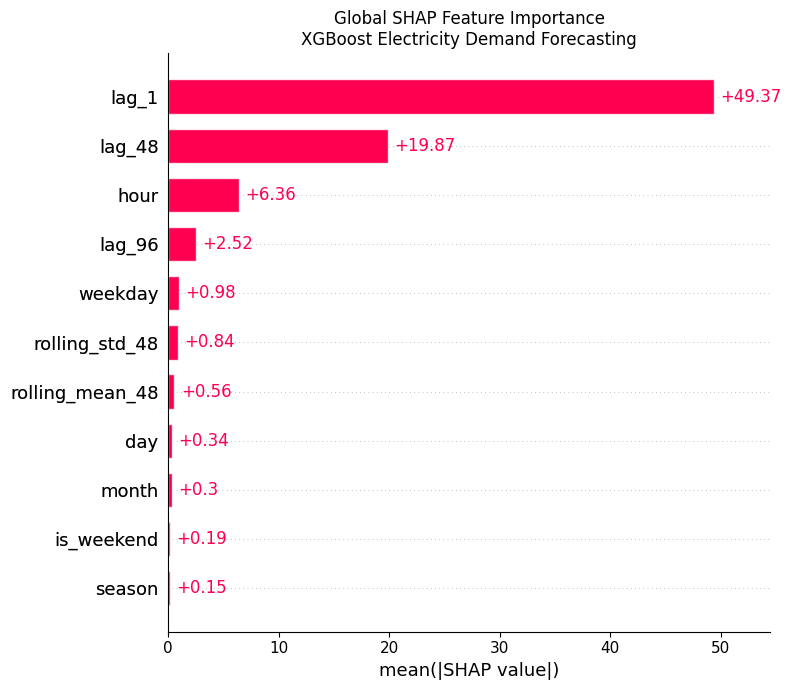

In [19]:
plt.figure(figsize=(10, 7))

shap.plots.bar(
    shap_explanation,
    max_display=len(features),
    show=False
)

plt.title(
    "Global SHAP Feature Importance\n"
    "XGBoost Electricity Demand Forecasting"
)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/shap_global_bar.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

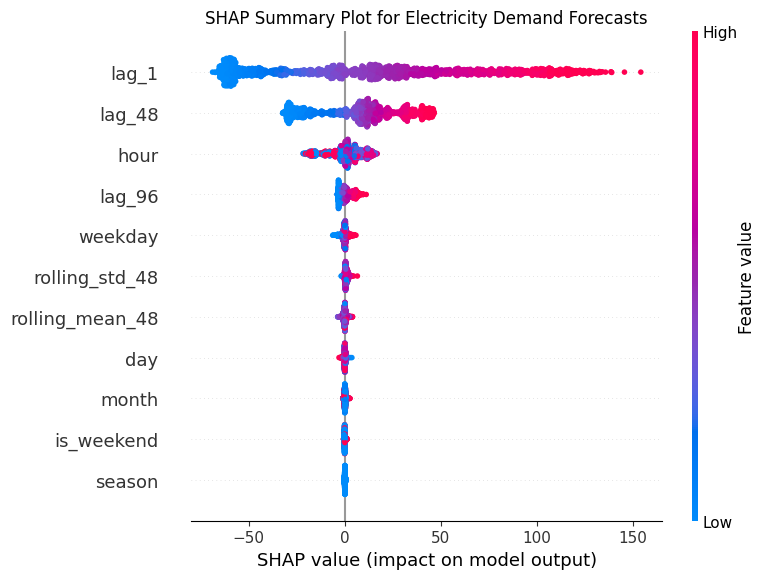

In [20]:
plt.figure(figsize=(11, 8))

shap.plots.beeswarm(
    shap_explanation,
    max_display=len(features),
    show=False
)

plt.title(
    "SHAP Summary Plot for Electricity Demand Forecasts"
)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/shap_beeswarm.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [21]:
top_three_features = (
    shap_importance["Feature"]
    .head(3)
    .tolist()
)

print("Top three SHAP features:")

for position, feature in enumerate(
    top_three_features,
    start=1
):
    print(position, feature)

Top three SHAP features:
1 lag_1
2 lag_48
3 hour


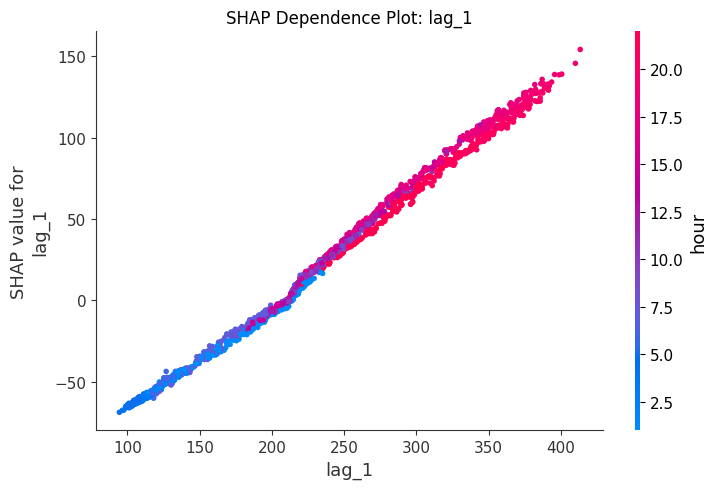

In [22]:
top_feature_1 = top_three_features[0]

shap.dependence_plot(
    top_feature_1,
    shap_explanation.values,
    X_shap,
    interaction_index="auto",
    show=False
)

plt.title(
    f"SHAP Dependence Plot: {top_feature_1}"
)

plt.tight_layout()

plt.savefig(
    f"../outputs/figures/shap_dependence_{top_feature_1}.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

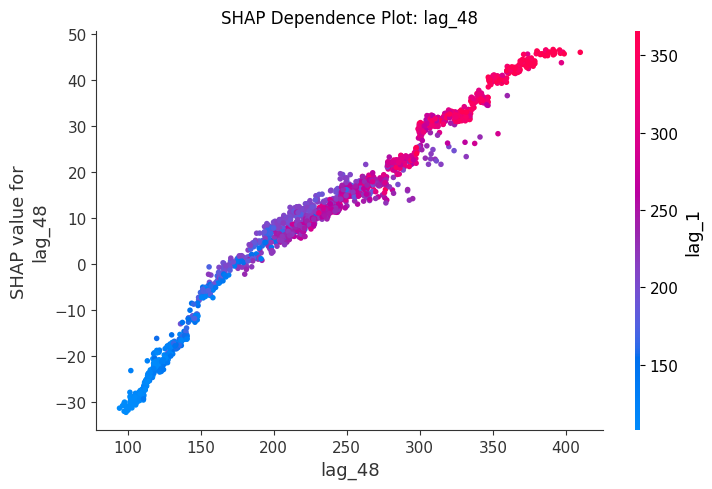

In [23]:
top_feature_2 = top_three_features[1]

shap.dependence_plot(
    top_feature_2,
    shap_explanation.values,
    X_shap,
    interaction_index="auto",
    show=False
)

plt.title(
    f"SHAP Dependence Plot: {top_feature_2}"
)

plt.tight_layout()

plt.savefig(
    f"../outputs/figures/shap_dependence_{top_feature_2}.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

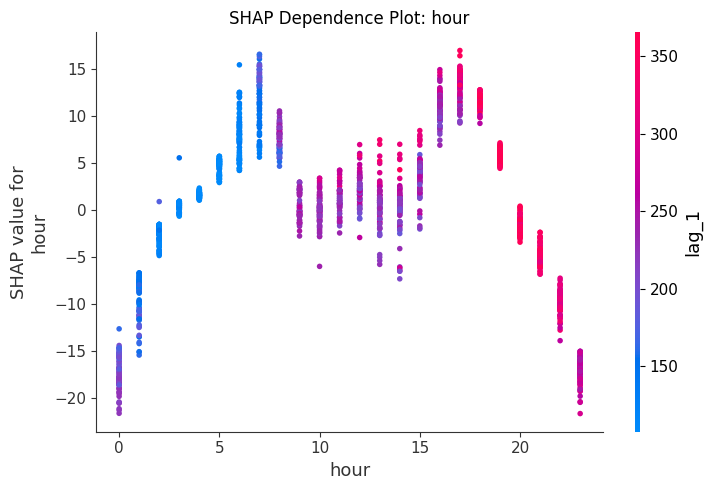

In [24]:
top_feature_3 = top_three_features[2]

shap.dependence_plot(
    top_feature_3,
    shap_explanation.values,
    X_shap,
    interaction_index="auto",
    show=False
)

plt.title(
    f"SHAP Dependence Plot: {top_feature_3}"
)

plt.tight_layout()

plt.savefig(
    f"../outputs/figures/shap_dependence_{top_feature_3}.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [25]:
prediction_results = pd.DataFrame({
    "Actual_Demand_kWh": y_test.values,
    "Predicted_Demand_kWh": y_pred
})

prediction_results["Absolute_Error_kWh"] = np.abs(
    prediction_results["Actual_Demand_kWh"]
    - prediction_results["Predicted_Demand_kWh"]
)

largest_error_position = int(
    prediction_results[
        "Absolute_Error_kWh"
    ].idxmax()
)

print(
    "Largest-error test position:",
    largest_error_position
)

display(
    prediction_results.iloc[
        [largest_error_position]
    ]
)


Largest-error test position: 476


,Actual_Demand_kWh,Predicted_Demand_kWh,Absolute_Error_kWh
476,333.842,371.926575,38.084575


In [26]:
local_row = X_test.iloc[
    [largest_error_position]
]

local_explanation = explainer(
    local_row
)

actual_value = float(
    y_test.iloc[largest_error_position]
)

predicted_value = float(
    y_pred[largest_error_position]
)

print(f"Actual demand:    {actual_value:.4f} kWh")
print(f"Predicted demand: {predicted_value:.4f} kWh")
print(
    f"Absolute error:   "
    f"{abs(actual_value - predicted_value):.4f} kWh"
)

Actual demand:    333.8420 kWh
Predicted demand: 371.9266 kWh
Absolute error:   38.0846 kWh


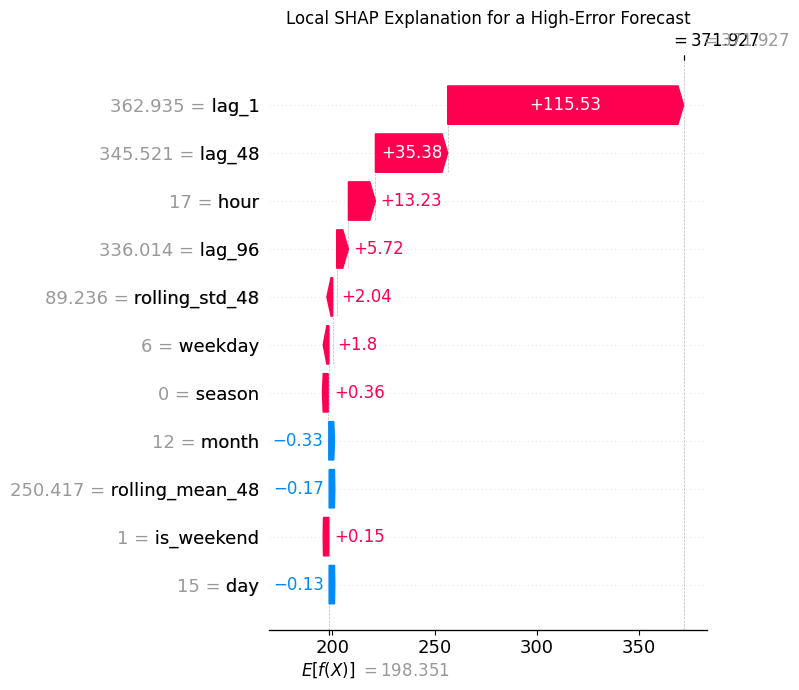

In [27]:
shap.plots.waterfall(
    local_explanation[0],
    max_display=len(features),
    show=False
)

plt.title(
    "Local SHAP Explanation for a High-Error Forecast"
)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/shap_local_waterfall.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [28]:
local_shap_table = pd.DataFrame({
    "Feature": features,
    "Feature_Value": local_row.iloc[0].values,
    "SHAP_Value": local_explanation.values[0]
})

local_shap_table["Absolute_SHAP_Value"] = np.abs(
    local_shap_table["SHAP_Value"]
)

local_shap_table = (
    local_shap_table
    .sort_values(
        "Absolute_SHAP_Value",
        ascending=False
    )
    .reset_index(drop=True)
)

display(local_shap_table)

local_shap_table.to_csv(
    "../outputs/tables/shap_local_explanation.csv",
    index=False
)

,Feature,Feature_Value,SHAP_Value,Absolute_SHAP_Value
0,lag_1,362.935000,115.526184,115.526184
1,lag_48,345.521000,35.375790,35.375790
2,hour,17.000000,13.233974,13.233974
3,lag_96,336.014000,5.724291,5.724291
4,rolling_std_48,89.236307,2.038886,2.038886
5,weekday,6.000000,1.802176,1.802176
6,season,0.000000,0.363597,0.363597
7,month,12.000000,-0.334220,0.334220
8,rolling_mean_48,250.417417,-0.168542,0.168542
9,is_weekend,1.000000,0.145482,0.145482


In [29]:
base_value = float(
    np.asarray(
        local_explanation.base_values
    ).reshape(-1)[0]
)

sum_of_shap_values = float(
    local_explanation.values[0].sum()
)

reconstructed_prediction = (
    base_value
    + sum_of_shap_values
)

print(f"Base value:               {base_value:.6f}")
print(f"Sum of SHAP contributions:{sum_of_shap_values:.6f}")
print(
    f"Reconstructed prediction: {reconstructed_prediction:.6f}"
)
print(f"Model prediction:         {predicted_value:.6f}")

difference = abs(
    reconstructed_prediction
    - predicted_value
)

print(f"Difference:               {difference:.10f}")

Base value:               198.350555
Sum of SHAP contributions:173.576035
Reconstructed prediction: 371.926590
Model prediction:         371.926575
Difference:               0.0000152588


In [30]:
if "datetime" in df.columns:
    prediction_results["datetime"] = (
        df["datetime"]
        .iloc[split_index:]
        .reset_index(drop=True)
    )

prediction_results.to_csv(
    "../outputs/tables/xgboost_test_predictions.csv",
    index=False
)

print("Prediction results saved.")

Prediction results saved.


In [31]:
top_feature = shap_importance.iloc[0]["Feature"]
second_feature = shap_importance.iloc[1]["Feature"]
third_feature = shap_importance.iloc[2]["Feature"]

print("PHASE 12 INTERPRETATION")
print("-----------------------")

print(
    f"The SHAP analysis identified {top_feature} as the "
    "most influential feature in the XGBoost electricity-demand "
    "forecasting model."
)

print(
    f"The next most important features were {second_feature} "
    f"and {third_feature}."
)

print(
    "This indicates that the model relies strongly on recent and "
    "historically corresponding demand observations when forecasting "
    "half-hourly local electricity demand."
)

print(
    "Calendar and seasonal variables provide additional information, "
    "but their overall influence is lower than the lagged-demand "
    "features."
)

print(
    "The local waterfall explanation also demonstrates how individual "
    "feature values increase or decrease a specific demand forecast."
)

PHASE 12 INTERPRETATION
-----------------------
The SHAP analysis identified lag_1 as the most influential feature in the XGBoost electricity-demand forecasting model.
The next most important features were lag_48 and hour.
This indicates that the model relies strongly on recent and historically corresponding demand observations when forecasting half-hourly local electricity demand.
Calendar and seasonal variables provide additional information, but their overall influence is lower than the lagged-demand features.
The local waterfall explanation also demonstrates how individual feature values increase or decrease a specific demand forecast.
